In [7]:
# ==========================================
# 1. CARREGAMENTO DE PACOTES
# ==========================================

#Pacotes

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
import scipy.stats as stats
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
import scikit_posthocs as sp

warnings.filterwarnings('ignore')

In [3]:
# ==========================================
# 1. CARREGAMENTO E VISUALIZAÇÃO DOS DADOS
# ==========================================

# 1. Definir os nomes das colunas de acordo com o ficheiro de atributos
columns = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free",
    "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
    "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money",
    "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
    "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
    "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology",
    "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
    "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project",
    "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_semicolon", "char_freq_parenthesis", "char_freq_bracket",
    "char_freq_exclamation", "char_freq_dollar", "char_freq_hash",
    "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total", "is_spam"
]

# 2. Carregar o ficheiro CSV/data sem cabeçalho
df = pd.read_csv("spambase.data", header=None, names=columns)

# 3. Métodos para visualização inicial
print(df.head())          # Exibe as primeiras 5 linhas tabuladas
print(df.info())          # Resumo de tipos e valores nulos
print(df["is_spam"].value_counts()) # Proporção entre spam (1) e legítimo (0)

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_semicolon  \
0             0.00            0.00  ...                 0.00   
1           

Iniciando varredura dos pares (K, H) com 100 repetições cada...
Par (K=2, H=1) -> Menor W = 256513.75 | Silhueta = 0.2961
Par (K=2, H=2) -> Menor W = 244486.70 | Silhueta = 0.6596
Par (K=3, H=1) -> Menor W = 254414.01 | Silhueta = 0.2515
Par (K=3, H=2) -> Menor W = 239373.66 | Silhueta = 0.2454
Par (K=3, H=3) -> Menor W = 234585.87 | Silhueta = 0.1409
Par (K=4, H=1) -> Menor W = 253278.68 | Silhueta = 0.0484
Par (K=4, H=2) -> Menor W = 233358.70 | Silhueta = 0.2428
Par (K=4, H=3) -> Menor W = 228516.44 | Silhueta = 0.1620
Par (K=4, H=4) -> Menor W = 227058.69 | Silhueta = 0.1536

Melhor combinação (K, H): (2, 2)
Número ótimo de clusters de objetos K* = 2 (Silhueta máxima = 0.6596)



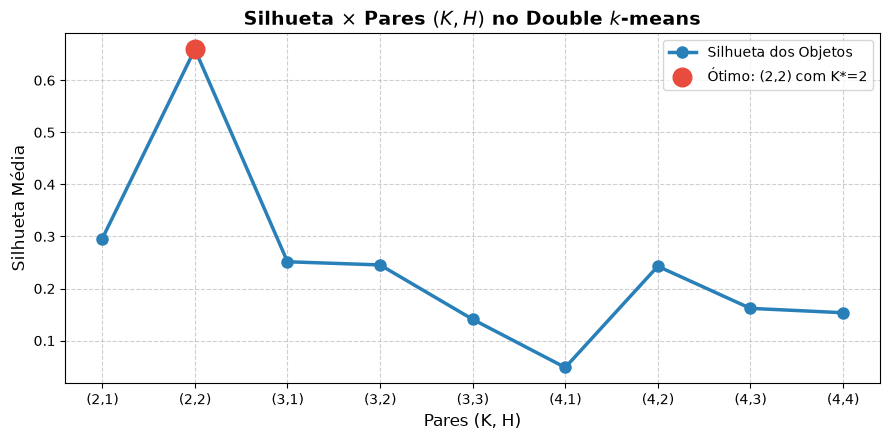

Índice de Rand Corrigido (ARI) para K* = 2: -0.0049
Comentário: O ARI varia de -1 a 1 (sendo 0 o valor esperado ao acaso e 1 partição idêntica).

--- Matriz de Protótipos dos Blocos (G) ---
               Bloco_Var_1  Bloco_Var_2
Cluster_Obj_1    -0.051080     0.001075
Cluster_Obj_2     6.861185    -0.144405


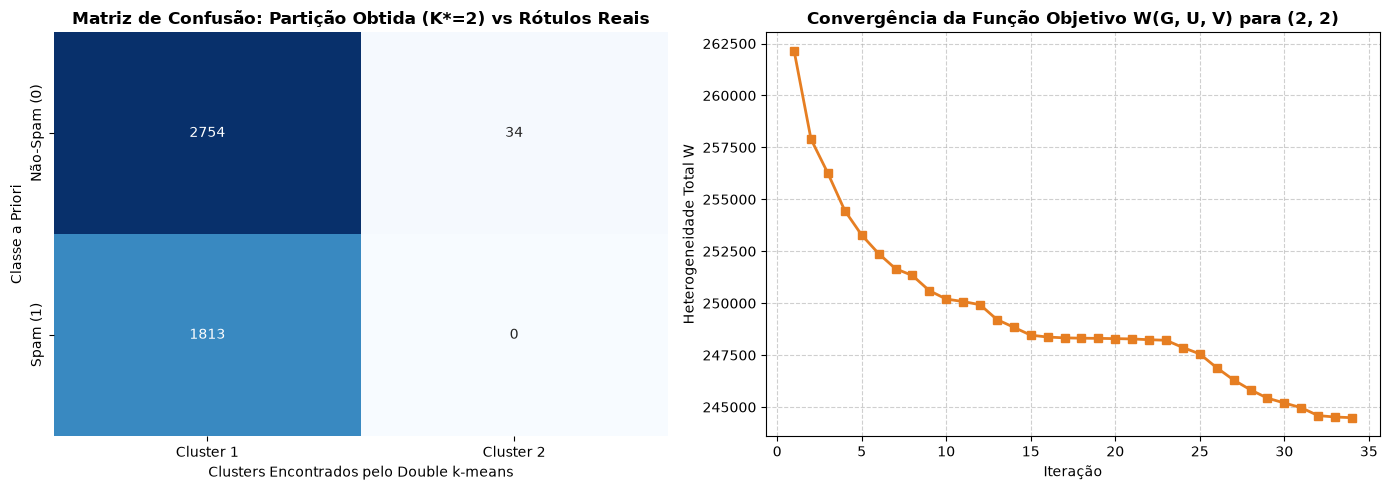

In [4]:
# ==========================================
# 1. QUESTÃO
# ==========================================
# 2. IMPLEMENTAÇÃO DO DOUBLE K-MEANS
# ==========================================

# --- DEFINIÇÃO DE X E y_true ---
# Separa atributos (X) e classe real (y_true)
X_raw = df.drop(columns=["is_spam"]).values
y_true = df["is_spam"].values

# No Double k-means, padronizar as colunas (z-score) é fundamental
# para que variáveis com escalas muito distintas (ex: run_length) não dominem os blocos
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)


def double_kmeans(X, K, H, max_iter=100, tol=1e-6, random_state=None):
    """
    Algoritmo Double k-means:
    Minimiza: W(G, U, V) = sum_{k=1}^K sum_{h=1}^H sum_{i=1}^N sum_{j=1}^P u_ik * v_jh * (x_ij - g_kh)^2
    """
    rng = np.random.RandomState(random_state)
    N, P = X.shape

    # Inicialização aleatória das pertinências crisp U e V
    u_labels = rng.randint(0, K, size=N)
    v_labels = rng.randint(0, H, size=P)

    # Garantir que todos os grupos tenham ao menos um elemento
    for k in range(K):
        if not np.any(u_labels == k):
            u_labels[rng.choice(N)] = k
    for h in range(H):
        if not np.any(v_labels == h):
            v_labels[rng.choice(P)] = h

    G = np.zeros((K, H))
    W_history = []

    for iteration in range(max_iter):
        # Passo 1: Otimização dos protótipos dos blocos g_kh
        for k in range(K):
            idx_obj = np.where(u_labels == k)[0]
            for h in range(H):
                idx_var = np.where(v_labels == h)[0]
                if len(idx_obj) > 0 and len(idx_var) > 0:
                    G[k, h] = np.mean(X[np.ix_(idx_obj, idx_var)])
                else:
                    G[k, h] = 0.0

        # Passo 2: Atualização da pertinência dos objetos (U)
        # Calcula a distância do objeto i até cada grupo de objetos k considerando os clusters de variáveis H
        # Dist_obj[i, k] = sum_h sum_{j in Q_h} (x_ij - g_kh)^2
        dist_u = np.zeros((N, K))
        for h in range(H):
            idx_var = np.where(v_labels == h)[0]
            if len(idx_var) == 0:
                continue
            X_sub = X[:, idx_var] # (N, n_h)
            for k in range(K):
                # Erro quadrático somado sobre as variáveis do bloco h
                dist_u[:, k] += np.sum((X_sub - G[k, h]) ** 2, axis=1)

        new_u_labels = np.argmin(dist_u, axis=1)

        # Evitar cluster de objetos vazio
        for k in range(K):
            if not np.any(new_u_labels == k):
                worst_obj = np.argmax(np.min(dist_u, axis=1))
                new_u_labels[worst_obj] = k

        # Passo 3: Atualização da pertinência das variáveis (V)
        # Dist_var[j, h] = sum_k sum_{i in P_k} (x_ij - g_kh)^2
        dist_v = np.zeros((P, H))
        for k in range(K):
            idx_obj = np.where(new_u_labels == k)[0]
            if len(idx_obj) == 0:
                continue
            X_sub = X[idx_obj, :] # (n_k, P)
            for h in range(H):
                dist_v[:, h] += np.sum((X_sub - G[k, h]) ** 2, axis=0)

        new_v_labels = np.argmin(dist_v, axis=1)

        # Evitar cluster de variáveis vazio
        for h in range(H):
            if not np.any(new_v_labels == h):
                worst_var = np.argmax(np.min(dist_v, axis=1))
                new_v_labels[worst_var] = h

        # Cálculo da Função Objetivo W(G, U, V)
        W = 0.0
        for k in range(K):
            idx_obj = np.where(new_u_labels == k)[0]
            for h in range(H):
                idx_var = np.where(new_v_labels == h)[0]
                if len(idx_obj) > 0 and len(idx_var) > 0:
                    W += np.sum((X[np.ix_(idx_obj, idx_var)] - G[k, h]) ** 2)

        W_history.append(W)

        # Critério de convergência: estabilização da atribuição ou estagnação da perda
        if np.array_equal(new_u_labels, u_labels) and np.array_equal(new_v_labels, v_labels):
            u_labels, v_labels = new_u_labels, new_v_labels
            break
        if iteration > 0 and abs(W_history[-2] - W_history[-1]) < tol:
            u_labels, v_labels = new_u_labels, new_v_labels
            break

        u_labels, v_labels = new_u_labels, new_v_labels

    return G, u_labels, v_labels, W, W_history

# ==========================================================
# 3. EXPERIMENTO: 100 EXECUÇÕES PARA CADA (K, H) E SILHUETA
# ==========================================================

K_values = [2, 3, 4]
results = {}
grid_pairs = []

print("Iniciando varredura dos pares (K, H) com 100 repetições cada...")

for K in K_values:
    for H in range(1, K + 1):
        pair = (K, H)
        grid_pairs.append(pair)
        best_W = np.inf
        best_run = None

        for run in range(100):
            G, u_labels, v_labels, W, W_hist = double_kmeans(
                X, K=K, H=H, max_iter=60, random_state=run * 100 + K * 10 + H
            )
            if W < best_W:
                best_W = W
                best_run = {
                    "G": G,
                    "u_labels": u_labels,
                    "v_labels": v_labels,
                    "W": W,
                    "W_history": W_hist
                }

        # Cálculo da silhueta para a partição de objetos
        sil = silhouette_score(X, best_run["u_labels"])
        best_run["silhouette"] = sil
        results[pair] = best_run

        print(f"Par (K={K}, H={H}) -> Menor W = {best_W:.2f} | Silhueta = {sil:.4f}")

# ==========================================================
# 4. DETERMINAÇÃO DE K* E PLOT Sil x (K, H)
# ==========================================================

pair_labels = [f"({k},{h})" for (k, h) in grid_pairs]
sil_values = [results[pair]["silhouette"] for pair in grid_pairs]

best_pair = grid_pairs[np.argmax(sil_values)]
K_star = best_pair[0]

print("\n" + "="*50)
print(f"Melhor combinação (K, H): {best_pair}")
print(f"Número ótimo de clusters de objetos K* = {K_star} (Silhueta máxima = {max(sil_values):.4f})")
print("="*50 + "\n")

# Gráfico da Silhueta x (K, H)
plt.figure(figsize=(9, 4.5))
plt.plot(pair_labels, sil_values, marker='o', color="#2980b9", linewidth=2.5, markersize=8, label="Silhueta dos Objetos")
max_idx = np.argmax(sil_values)
plt.scatter([pair_labels[max_idx]], [sil_values[max_idx]], color="#e74c3c", s=180, zorder=5,
            label=f"Ótimo: {pair_labels[max_idx]} com K*={K_star}")

plt.title("Silhueta $\\times$ Pares $(K, H)$ no Double $k$-means", fontsize=14, fontweight="bold")
plt.xlabel("Pares (K, H)", fontsize=12)
plt.ylabel("Silhueta Média", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# ==========================================================
# 5. AVALIAÇÃO DA PARTIÇÃO COM K*
# ==========================================================

optimal_run = results[best_pair]
u_star = optimal_run["u_labels"]
G_star = optimal_run["G"]
W_history_star = optimal_run["W_history"]

# (a) Índice de Rand Corrigido (ARI)
ari = adjusted_rand_score(y_true, u_star)
print(f"Índice de Rand Corrigido (ARI) para K* = {K_star}: {ari:.4f}")
print("Comentário: O ARI varia de -1 a 1 (sendo 0 o valor esperado ao acaso e 1 partição idêntica).")

# (b) Matriz de Protótipos dos Blocos (G)
print("\n--- Matriz de Protótipos dos Blocos (G) ---")
df_prototypes = pd.DataFrame(
    G_star,
    index=[f"Cluster_Obj_{k+1}" for k in range(K_star)],
    columns=[f"Bloco_Var_{h+1}" for h in range(best_pair[1])]
)
print(df_prototypes)

# (c) Matriz de Confusão: Partição Obtida vs Partição a Priori
cm = confusion_matrix(y_true, u_star)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
            xticklabels=[f"Cluster {k+1}" for k in range(K_star)],
            yticklabels=["Não-Spam (0)", "Spam (1)"], ax=axes[0])
axes[0].set_title(f"Matriz de Confusão: Partição Obtida (K*={K_star}) vs Rótulos Reais", fontweight="bold")
axes[0].set_xlabel("Clusters Encontrados pelo Double k-means")
axes[0].set_ylabel("Classe a Priori")

# (d) Plot da Função Objetivo versus Iterações
axes[1].plot(range(1, len(W_history_star) + 1), W_history_star, marker='s', color="#e67e22", linewidth=2)
axes[1].set_title(f"Convergência da Função Objetivo W(G, U, V) para {best_pair}", fontweight="bold")
axes[1].set_xlabel("Iteração")
axes[1].set_ylabel("Heterogeneidade Total W")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# QUESTÃO 2: COMPARAÇÃO DE CLASSIFICADORES (VALIDAÇÃO 30x10-FOLDS)
# =============================================================================

# =============================================================================
# ETAPA 1: Definição dos Dois Datasets (Original vs Double k-means K*)
# =============================================================================
# Carrega os dados caso não estejam na memória
if 'X' not in locals() or 'y_orig' not in locals():
    data = pd.read_csv('spambase.data', header=None).values
    X = data[:, :-1].astype(float)
    y_true = data[:, -1].astype(int)
else:
    # Se y_orig já existia no ambiente, reaproveita
    y_true = y_orig.astype(int)

# y_orig: classes originais (0 e 1)
# u_star: rótulos obtidos da melhor execução da Questão 1 com K*
y_orig = y_true.astype(int)
y_clust = u_star.astype(int)

datasets = {
    "Original (2 classes)": (X, y_orig),
    f"Double k-means (K* = {K_star} classes)": (X, y_clust)
}

# =============================================================================
# ETAPA 2: Classificadores Bayesianos Customizados
# =============================================================================

class GaussianBayesClassifier(ClassifierMixin, BaseEstimator):
    """
    Classificador Bayesiano Gaussiano com Estimativas de MV:
    mu_i = media amostral, Sigma_i = matriz de covariancia amostral
    """
    _estimator_type = "classifier"

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.covs_ = {}
        n_samples, n_features = X.shape

        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / n_samples
            self.means_[c] = np.mean(X_c, axis=0)
            # Regularizacao numerica para garantir invertibilidade
            cov = np.cov(X_c, rowvar=False) + 1e-4 * np.eye(n_features)
            self.covs_[c] = cov
        return self

    def predict_proba(self, X):
        probas = []
        for c in self.classes_:
            try:
                p_x_given_c = stats.multivariate_normal.pdf(
                    X, mean=self.means_[c], cov=self.covs_[c], allow_singular=True
                )
            except Exception:
                p_x_given_c = np.full(len(X), 1e-300)
            probas.append(p_x_given_c * self.priors_[c])

        probas = np.array(probas).T
        sums = probas.sum(axis=1, keepdims=True)
        sums[sums == 0] = 1.0
        return probas / sums

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


class ParzenBayesClassifier(ClassifierMiAdicionar todas as alteraçxin, BaseEstimator):
    """
    Classificador Bayesiano baseado na Janela de Parzen
    com Kernel Gaussiano produto multivariado (OTIMIZADO PARA MEMÓRIA RAM).
    """
    _estimator_type = "classifier"

    def __init__(self, h=1.0):
        self.h = h

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.X_train_ = np.ascontiguousarray(X)
        self.y_train_ = np.ascontiguousarray(y)
        self.priors_ = {c: np.mean(y == c) for c in self.classes_}
        return self

    def predict_proba(self, X):
        n_samples, d = X.shape
        h = max(float(self.h), 1e-2)
        probas = np.zeros((n_samples, leAdicionar todas as alteraçn(self.classes_)))

        for idx, c in enumerate(self.classes_):
            X_c = self.X_train_[self.y_train_ == c]
            n_c = len(X_c)
            norm_factor = n_c * ((2 * np.pi) ** (d / 2.0)) * (h ** d) + 1e-300
            
            # Processa cada amostra individualmente para evitar matriz 3D gigante na RAM
            density = np.zeros(n_samples)
            for i in range(n_samples):
                dists_sq = np.sum((X_c - X[i]) ** 2, axis=1)
                density[i] = np.sum(np.exp(-0.5 * dists_sq / (h ** 2))) / norm_factor

            probas[:, idx] = density * self.priors_[c]

        sums = probas.sum(axis=1, keepdims=True)
        sums[sums == 0] = 1.0
        return probas / sums

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

# =============================================================================
# ETAPA 3: Ajuste de Hiperparâmetros via Validação Cruzada 5-folds Aninhada
# =============================================================================
def get_tuned_models(X_train, y_train):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 1. Bayesiano Gaussiano (MV)
    clf_bayes = GaussianBayesClassifier().fit(X_train, y_train)

    # 2. k-NN (Distâncias: Euclidiana, City-block/Manhattan e Chebishev)
    knn_params = {
        'n_neighbors': [3, 5, 7, 9],
        'metric': ['euclidean', 'manhattan', 'chebyshev']
    }
    grid_knn = GridSearchCV(
        KNeighborsClassifier(), knn_params, cv=inner_cv,
        scoring='f1_macro', n_jobs=2
    )
    grid_knn.fit(X_train, y_train)
    clf_knn = grid_knn.best_estimator_

    # 3. Janela de Parzen (Kernel Produto)
    parzen_params = {'h': [0.5, 1.0, 2.0]}
    grid_parzen = GridSearchCV(
        ParzenBayesClassifier(), parzen_params, cv=inner_cv,
        scoring='f1_macro', n_jobs=2
    )
    grid_parzen.fit(X_train, y_train)
    clf_parzen = grid_parzen.best_estimator_

    # 4. Regressão Logística
    lr_params = {'C': [0.01, 0.1, 1.0, 10.0]}
    grid_lr = GridSearchCV(
        LogisticRegression(max_iter=1000), lr_params, cv=inner_cv,
        scoring='f1_macro', n_jobs=2
    )
    grid_lr.fit(X_train, y_train)
    clf_lr = grid_lr.best_estimator_

    # 5. Voto Majoritário baseado nos 4 classificadores
    clf_voting = VotingClassifier(
        estimators=[
            ('bayes', clf_bayes),
            ('knn', clf_knn),
            ('parzen', clf_parzen),
            ('lr', clf_lr)
        ],
        voting='hard'
    )
    clf_voting.fit(X_train, y_train)

    # Limpeza de variáveis do GridSearch para liberar RAM
    del grid_knn, grid_parzen, grid_lr
    gc.collect()

    return {
        'Bayesiano Gaussiano': clf_bayes,
        'k-NN': clf_knn,
        'Janela de Parzen': clf_parzen,
        'Regr. Logística': clf_lr,
        'Voto Majoritário': clf_voting
    }

# =============================================================================
# ETAPA 4: Validação Cruzada Estratificada 30x10-folds
# =============================================================================
def evaluate_dataset(X_data, y_data):
    model_names = ['Bayesiano Gaussiano', 'k-NN', 'Janela de Parzen', 'Regr. Logística', 'Voto Majoritário']
    metric_names = ['Taxa de Erro', 'Precisão', 'Cobertura', 'F-measure']

    results = {m: {clf: [] for clf in model_names} for m in metric_names}
    is_binary = len(np.unique(y_data)) == 2
    avg_mode = 'binary' if is_binary else 'macro'

    print(f"Executando 30x10-folds para conjunto com {len(np.unique(y_data))} classes...")

    for rep in range(30):
        print(f" -> Processando Repetição {rep+1}/30...")
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=rep)

        for train_idx, test_idx in skf.split(X_data, y_data):
            X_tr, X_te = X_data[train_idx], X_data[test_idx]
            y_tr, y_te = y_data[train_idx], y_data[test_idx]

            # Treina modelos com ajuste de hiperparâmetros nos 9 folds
            models = get_tuned_models(X_tr, y_tr)

            for name, model in models.items():
                y_pred = model.predict(X_te)

                err = 1.0 - accuracy_score(y_te, y_pred)
                prec = precision_score(y_te, y_pred, average=avg_mode, zero_division=0)
                rec = recall_score(y_te, y_pred, average=avg_mode, zero_division=0)
                f1 = f1_score(y_te, y_pred, average=avg_mode, zero_division=0)

                results['Taxa de Erro'][name].append(err)
                results['Precisão'][name].append(prec)
                results['Cobertura'][name].append(rec)
                results['F-measure'][name].append(f1)

            # Limpeza do dicionário de modelos a cada fold
            del models
            gc.collect()

    return results

# Executa para os dois conjuntos
dataset_results = {}
for name, (X_curr, y_curr) in datasets.items():
    print(f"\n>>> Avaliando versão: {name}")
    dataset_results[name] = evaluate_dataset(X_curr, y_curr)

# =============================================================================
# ETAPA 5: Estimativas Pontuais, IC (95%), Friedman e Nemenyi
# =============================================================================
for d_name, res in dataset_results.items():
    print("\n" + "="*70)
    print(f"RESULTADOS ESTATÍSTICOS: {d_name}")
    print("="*70)

    for metric, clfs in res.items():
        print(f"\n--- Métrica: {metric} ---")
        data_matrix = []

        for clf_name, values in clfs.items():
            mean_val = np.mean(values)
            std_err = stats.sem(values)
            ci = stats.t.interval(0.95, len(values) - 1, loc=mean_val, scale=std_err)
            print(f"{clf_name:20s} | Média: {mean_val:.4f} | IC 95%: [{ci[0]:.4f}, {ci[1]:.4f}]")
            data_matrix.append(values)

        # Teste de Friedman
        stat, p_val = stats.friedmanchisquare(*data_matrix)
        print(f"Friedman test: Estatística = {stat:.4f}, p-valor = {p_val:.4e}")

        # Pós-teste de Nemenyi se houver diferença estatisticamente significante
        if p_val < 0.05:
            df_friedman = pd.DataFrame(np.array(data_matrix).T, columns=list(clfs.keys()))
            nemenyi = sp.posthoc_nemenyi_friedman(df_friedman)
            print("Pós-teste de Nemenyi (Matriz de p-valores):")
            print(nemenyi.round(4))

# =============================================================================
# ETAPA 6: Curvas de Aprendizagem (F-measure) de 5% a 95%
# =============================================================================
print("\nGerando Curvas de Aprendizagem (5% a 95%)...")
X_eval, y_eval = datasets["Original (2 classes)"]
train_fractions = np.linspace(0.05, 0.95, 19)

learning_curves = {
    clf: {'train': [], 'test': []}
    for clf in ['Bayesiano Gaussiano', 'k-NN', 'Janela de Parzen', 'Regr. Logística', 'Voto Majoritário']
}

for frac in train_fractions:
    # Divisao estratificada com fração de teste (1 - frac)
    n_splits = int(np.round(1 / min(frac, 1.0 - frac)))
    n_splits = max(2, min(n_splits, 20))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_idx, test_idx = next(skf.split(X_eval, y_eval))

    target_train_size = int(len(X_eval) * frac)
    if len(train_idx) > target_train_size:
        train_idx = np.random.RandomState(42).choice(train_idx, size=target_train_size, replace=False)

    X_tr, y_tr = X_eval[train_idx], y_eval[train_idx]
    X_te, y_te = X_eval[test_idx], y_eval[test_idx]

    models = get_tuned_models(X_tr, y_tr)

    for name, model in models.items():
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)

        learning_curves[name]['train'].append(f1_score(y_tr, pred_tr, average='binary', zero_division=0))
        learning_curves[name]['test'].append(f1_score(y_te, pred_te, average='binary', zero_division=0))

    del models
    gc.collect()

# Plot das Curvas
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (name, scores), c in zip(learning_curves.items(), colors):
    plt.plot(train_fractions, scores['test'], label=f"{name} (Teste)", color=c, linewidth=2)
    plt.plot(train_fractions, scores['train'], linestyle='--', color=c, alpha=0.45)

plt.title("Curvas de Aprendizagem (F-measure) vs. Fração de Treino (5% a 95%)", fontsize=14, fontweight="bold")
plt.xlabel("Proporção do Conjunto de Treinamento", fontsize=12)
plt.ylabel("F-measure", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


>>> Avaliando versão: Original (2 classes)
Executando 30x10-folds para conjunto com 2 classes...
 -> Processando Repetição 1/30...
 -> Processando Repetição 2/30...
 -> Processando Repetição 3/30...
 -> Processando Repetição 4/30...
 -> Processando Repetição 5/30...
 -> Processando Repetição 6/30...
 -> Processando Repetição 7/30...
 -> Processando Repetição 8/30...
